# Regression Model Cross-Validation using Molecular Descriptors

In [1]:
import random 
from random import sample, seed, shuffle
import numpy as np
import pandas as pd
import os
import six
from rdkit import rdBase
from rdkit import RDLogger

# Suppress RDKit warnings
rdBase.DisableLog('rdApp.*')
RDLogger.DisableLog('rdApp.*')

#utility functions : prepare the data 
from model_fp_selection.lib.utils import prepare_df_morgan, prepare_df_rdkit, swap_identical_ligands
from model_fp_selection.lib.utils import drop_duplicates, average_duplicates, calc_desc

#utility functions : CV and results 
from model_fp_selection.lib.utils import obtain_metrics, plot_cv_results
from model_fp_selection.lib.utils import df_split, get_indices, get_indices_doi, get_indices_scaff
from model_fp_selection.lib.utils import generate_scaffold, scaffold_to_smiles
from model_fp_selection.lib.utils import ligands_permutation, cross_validation, prepare_train_set


from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs, Draw
from sklearn.model_selection import KFold, GridSearchCV, GroupKFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, median_absolute_error, PredictionErrorDisplay
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_validate
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.preprocessing import MinMaxScaler

#Encoding categorical Data
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.preprocessing import StandardScaler

# Regressors
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import GradientBoostingRegressor

#Pipelines and other model constructions
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer

# Visualization
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 20})

#np.random.seed(42)
#seed(42)

#Specific to Scaffold Splitting
from rdkit.Chem.Scaffolds import MurckoScaffold
from collections import defaultdict
import pickle as pkl
import time
from tqdm import tqdm
import seaborn as sns

from itertools import *

from model_fp_selection.lib.cross_val_both_models import cross_val_2_models

## Preparing the dataset

In [2]:
metals= pd.read_csv("ruthenium_complexes_dataset_charges.csv", dtype={'L1': str, 'L2': str, 'L3': str})

In [3]:
metals_rdkit = prepare_df_rdkit(metals)

In [4]:
metals_rdkit = average_duplicates(metals_rdkit, 'Ligands_Tuple', 'pIC50')

Length of training dataset after cleaning duplicates, before adding permutations : 715


## Computing molecular descriptor representation from RDKit

In [5]:
metals_rdkit = calc_desc(metals_rdkit)

## Splitting the dataset

We can split the dataset in different manners. 
- First, we can split it so that no permutation groups are split between training and testing set. The splitting indices are given by the function **get_indices**.
- We can also split by DOI, so that two complexes from the same paper always end up in the same set. The splitting indices are given by the function **get_indices_doi**.
- We can also split by scaffold, so that two complexes sharing a similar scaffold end up in the same set. The splitting indices are given by the function **get_indices_scaffold**.

# Training the model

The parameters of the random forest were chosen by running Bayesian Optimisation on the hyperparameters search space with the descriptor representation. 

In [6]:
rf = RandomForestRegressor(max_depth=29, n_estimators=320, min_samples_leaf=1, max_features=0.4, random_state=42, n_jobs=16)



- we keep the idea of expanding the dataset with permutations but that should only be the case for the training set, not the test set. Permutations : The idea here is to create a unique ID for each unique complex, and then expand the dataset with permutations of ligands. That is, for a complex with 3 ligands A, B and C (in that order), adding the complexes with ligands (C, A, B), (A, C, B), etc. We keep all values identical apart from switching the ligands with one another. This is done during dataset preparation.

- we keep the scaler but we fit it on the training set only (and then scale it), and use the acquired parameters to scale the testing set. This is done within the cross validation function. 

## Standart Splitting

#### On the whole dataset

In [11]:
metals_rdkit_copy = metals_rdkit.copy()

X = np.array(metals_rdkit_copy['Descriptors'].values.tolist())
y = np.array(metals_rdkit_copy['pIC50'].values.tolist())

indices_metals = get_indices(metals_rdkit_copy, CV=10, shuffle=True)

train length : 643 | test length : 72
train length : 643 | test length : 72
train length : 643 | test length : 72
train length : 643 | test length : 72
train length : 643 | test length : 72
train length : 644 | test length : 71
train length : 644 | test length : 71
train length : 644 | test length : 71
train length : 644 | test length : 71
train length : 644 | test length : 71


In [12]:
y_data, y_predictions = cross_validation(metals_rdkit_copy, indices_metals, X, y, rf, descriptors=True)

CV iteration 0
CV iteration 1
CV iteration 2
CV iteration 3
CV iteration 4
CV iteration 5
CV iteration 6
CV iteration 7
CV iteration 8
CV iteration 9
{'MAE': 0.3301139762763986, 'RMSE': 0.4425926544611802, 'Ratio': 1.3407267982213669, 'R² Score': 0.7173467258001649}


0.7173467258001649

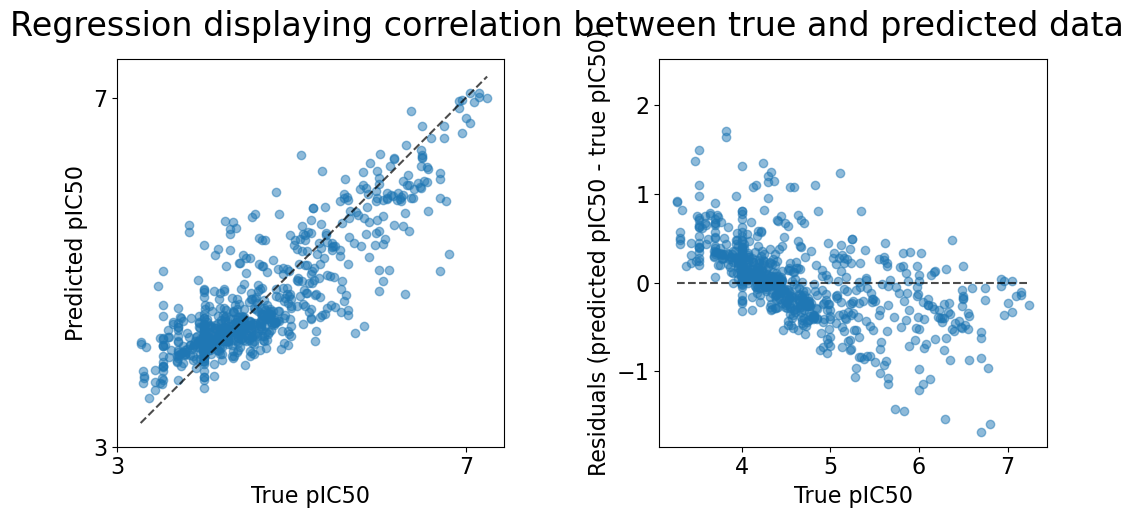

In [13]:
plot_cv_results(y_data, y_predictions, log=True)

In [14]:
desc_charges = pd.DataFrame()
desc_charges['data'] = y_data
desc_charges['predictions'] = y_predictions
s=[]
for i in range(10):
    s=s+indices_metals[i][1].tolist()
desc_charges['indices'] = s

desc_charges=desc_charges.sort_values(by='indices')
desc_charges.to_csv('desc_AAB.csv')

#### On HeLa cells

In [12]:
metals_hela = metals_rdkit.copy()
metals_hela = metals_hela[metals_hela['Cells'] == 'HeLa']
metals_hela.reset_index(drop=True, inplace=True)

X_hela = np.array(metals_hela['Descriptors'].values.tolist())
y_hela = np.array(metals_hela['pIC50'].values.tolist())

indices_hela = get_indices(metals_hela, CV=10, shuffle=True)

train length : 164 | test length : 19
train length : 164 | test length : 19
train length : 164 | test length : 19
train length : 165 | test length : 18
train length : 165 | test length : 18
train length : 165 | test length : 18
train length : 165 | test length : 18
train length : 165 | test length : 18
train length : 165 | test length : 18
train length : 165 | test length : 18


In [13]:
y_data_hela, y_predictions_hela = cross_validation(metals_hela, indices_hela, X_hela, y_hela, rf, descriptors=True)

CV iteration 0
CV iteration 1
CV iteration 2
CV iteration 3
CV iteration 4
CV iteration 5
CV iteration 6
CV iteration 7
CV iteration 8
CV iteration 9
{'MAE': 0.2809247582909046, 'RMSE': 0.37979182571140835, 'Ratio': 1.3519343329580245, 'R² Score': 0.5553929186541631}


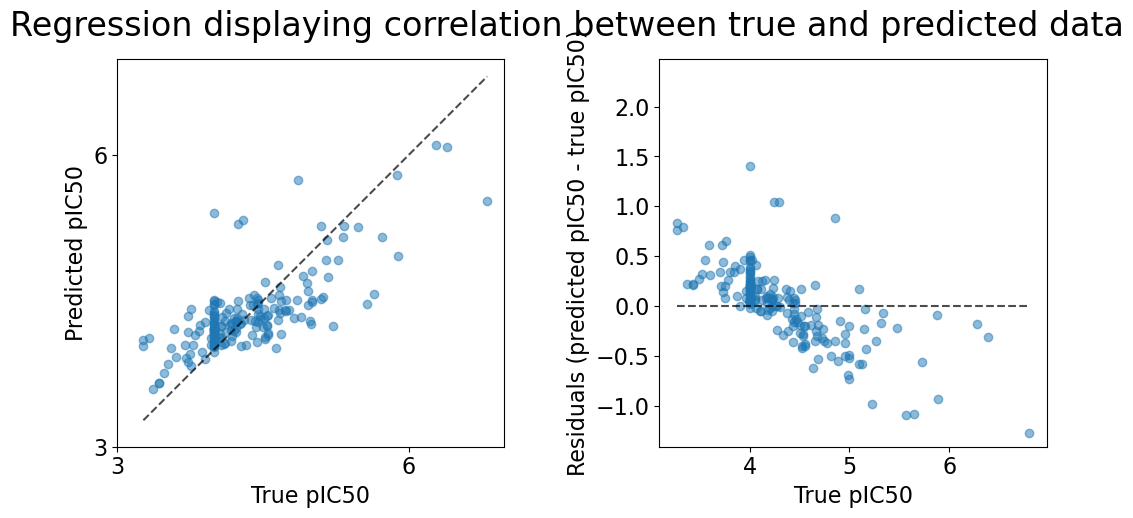

In [14]:
plot_cv_results(y_data_hela, y_predictions_hela, log=True)

## DOI Splitting

We split the dataset based on the DOI.

#### Training the model on the whole dataset

In [7]:
metals_doi_copy = metals_rdkit.copy()

#We drop any row where the descriptors contains a NaN value, as the model will not take any NaN value.
for index, array in enumerate(metals_doi_copy['Descriptors']):
    if np.isnan(array).any():
        metals_doi_copy.drop(index, inplace=True)
metals_doi_copy.reset_index(drop=True, inplace=True)

X_doi = np.array(metals_doi_copy['Descriptors'].values.tolist())
y_doi = np.array(metals_doi_copy['pIC50'].values.tolist())

indices_metals_doi = get_indices_doi(metals_doi_copy, CV=10)

fold 0 groups: train 196 test 21
fold 0 train set : 643 | test set : 72
fold 1 groups: train 196 test 21
fold 1 train set : 643 | test set : 72
fold 2 groups: train 195 test 22
fold 2 train set : 643 | test set : 72
fold 3 groups: train 195 test 22
fold 3 train set : 643 | test set : 72
fold 4 groups: train 195 test 22
fold 4 train set : 643 | test set : 72
fold 5 groups: train 196 test 21
fold 5 train set : 644 | test set : 71
fold 6 groups: train 195 test 22
fold 6 train set : 644 | test set : 71
fold 7 groups: train 195 test 22
fold 7 train set : 644 | test set : 71
fold 8 groups: train 195 test 22
fold 8 train set : 644 | test set : 71
fold 9 groups: train 195 test 22
fold 9 train set : 644 | test set : 71


In [8]:
y_data_doi, y_predictions_doi = cross_validation(metals_doi_copy, indices_metals_doi, X_doi, y_doi, rf, descriptors=True)

CV iteration 0
CV iteration 1
CV iteration 2
CV iteration 3
CV iteration 4
CV iteration 5
CV iteration 6
CV iteration 7
CV iteration 8
CV iteration 9
{'MAE': 0.4568007777246911, 'RMSE': 0.5917507180872847, 'Ratio': 1.2954240599912608, 'R² Score': 0.494730359436367}


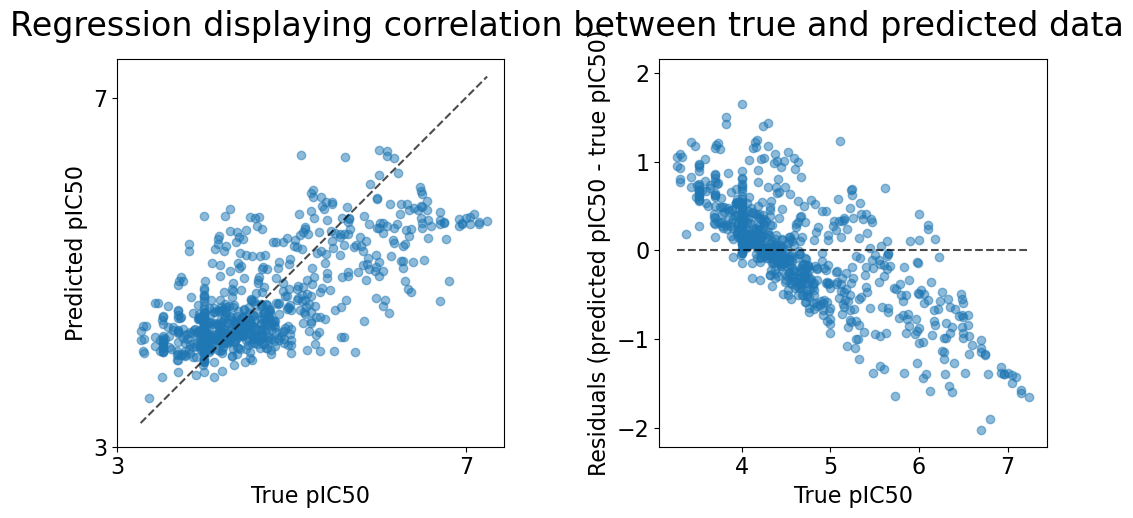

In [9]:
plot_cv_results(y_data_doi, y_predictions_doi, log=True)

In [10]:
desc_doi_charges = pd.DataFrame()
desc_doi_charges['data'] = y_data_doi
desc_doi_charges['predictions'] = y_predictions_doi
s=[]
for i in range(10):
    s=s+indices_metals_doi[i][1]
desc_doi_charges['indices'] = s

desc_doi_charges=desc_doi_charges.sort_values(by='indices')
desc_doi_charges.to_csv('desc_doi_AAB_rand.csv')

## Scaffold Splitting

Whenever the complexe presents a AAB structure, it has been canonicalized in the 'prepare_df' function, so that any complexes represented as ABA or BAA is put in the form AAB.

#### Why do we want to formatting all complexes with 2 identical ligands to the AAB Structure?

The Scaffold Splitting is done by analyzing the scaffolds of only one column of the ligands. As our dataset contains a majority of complexes with the AAB structure (2 first ligands are identical, the third is different), we want to make sure that the two identical ligands AA are in the 1st and 2nd position (columns L1 and L2), and the third one in the L3 column.

Therefore, we can do the scaffold splitting by analyzing the A ligand (splitting by L1 column) or the B ligand (L3 column). However, we should keep in mind than not all complexes are AAB. Some are AAA, some ABC. This technique est therefore a way to standardize only a part of the dataset.

**Idea for improvement** :  *do several splittings, where metals with ABC structure have their A logand in the splitting column, then their B ligand in the splitting column, then their C ligand in the splitting column. The AAB and AAA ligands remain unchanged. Then take the average result.*

#### Scaffold for ligand A

In [19]:
metals_A = metals_rdkit.copy()

#We drop any row where the descriptors contains a NaN value, as the model will not take any NaN value.
for index, array in enumerate(metals_A['Descriptors']):
    if np.isnan(array).any():
        metals_A.drop(index, inplace=True)
metals_A.reset_index(drop=True, inplace=True)

metals_A = average_duplicates(metals_A, 'Descriptors', 'pIC50')

X_A = np.array(metals_A['Descriptors'].values.tolist())
y_A = np.array(metals_A['pIC50'].values.tolist())

molsA = metals_A['MOL1'].tolist()

# We must extract the mol objects as the get_indices_scaff take a list of mol objects as argument, not a dataframe

indicesA = get_indices_scaff(molsA, CV=10)

TypeError: unhashable type: 'numpy.ndarray'

In [ ]:
y_dataA, y_predictionsA = cross_validation(metals_A, indicesA, X_A, y_A, rf, descriptors=True)

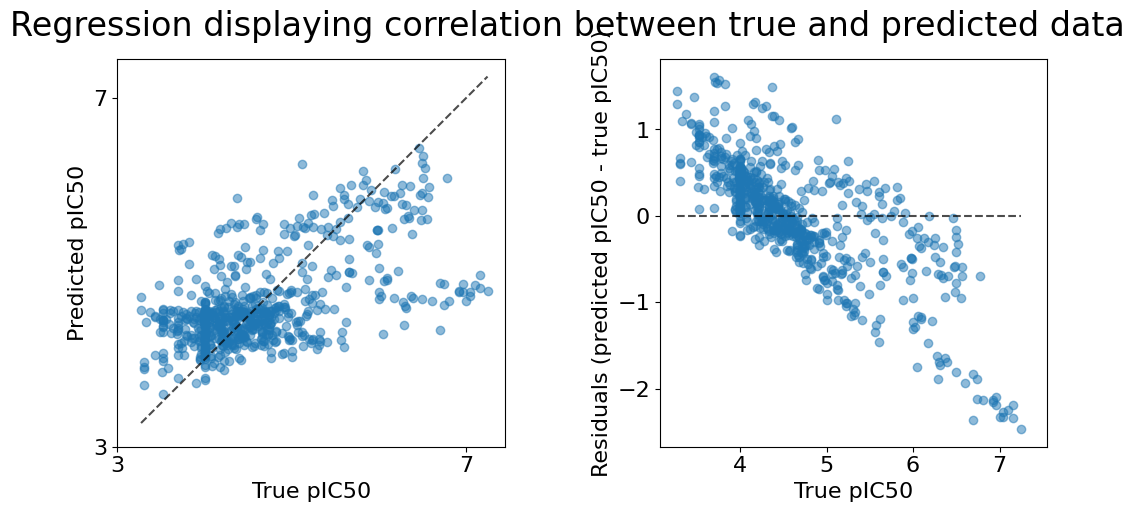

In [21]:
plot_cv_results(y_dataA, y_predictionsA, log=True)

#### Scaffold for ligand B

In [18]:
metals_B = metals_rdkit.copy()
#metals_B["MOL3"] = metals_B["L3"].apply(Chem.MolFromSmiles)


X_B = np.array(metals_B['Descriptors'].values.tolist())
y_B = np.array(metals_B['pIC50'].values.tolist())

molsB = metals_B['MOL3'].tolist()

# We must extract the mol objects as the get_indices_scaff take a list of mol objects as argument, not a dataframe

indicesB = get_indices_scaff(molsB, CV=10)

100%|██████████████████████████████████████████████████████████████████████████████| 715/715 [00:00<00:00, 4020.31it/s]

train length : 669 | test length : 46
train length : 647 | test length : 68
train length : 670 | test length : 45
train length : 572 | test length : 143
train length : 676 | test length : 39
train length : 663 | test length : 52
train length : 656 | test length : 59
train length : 569 | test length : 146
train length : 665 | test length : 50
train length : 648 | test length : 67


In [19]:
y_dataB, y_predictionsB = cross_validation(metals_B, indicesB, X_B, y_B, rf, descriptors=True)

CV iteration 0
CV iteration 1
CV iteration 2
CV iteration 3
CV iteration 4
CV iteration 5
CV iteration 6
CV iteration 7
CV iteration 8
CV iteration 9
{'MAE': 0.41544651142322697, 'RMSE': 0.5449824483856341, 'Ratio': 1.3117993132705483, 'R² Score': 0.5714409720459207}


In [20]:
desc_scaffB = pd.DataFrame()
desc_scaffB['data'] = y_dataB
desc_scaffB['predictions'] = y_predictionsB
s=[]
for i in range(10):
    s=s+indicesB[i][1]
desc_scaffB['indices'] = s

desc_scaffB=desc_scaffB.sort_values(by='indices')

In [21]:
desc_scaffB.to_csv('descB_clean_200_scaff.csv')

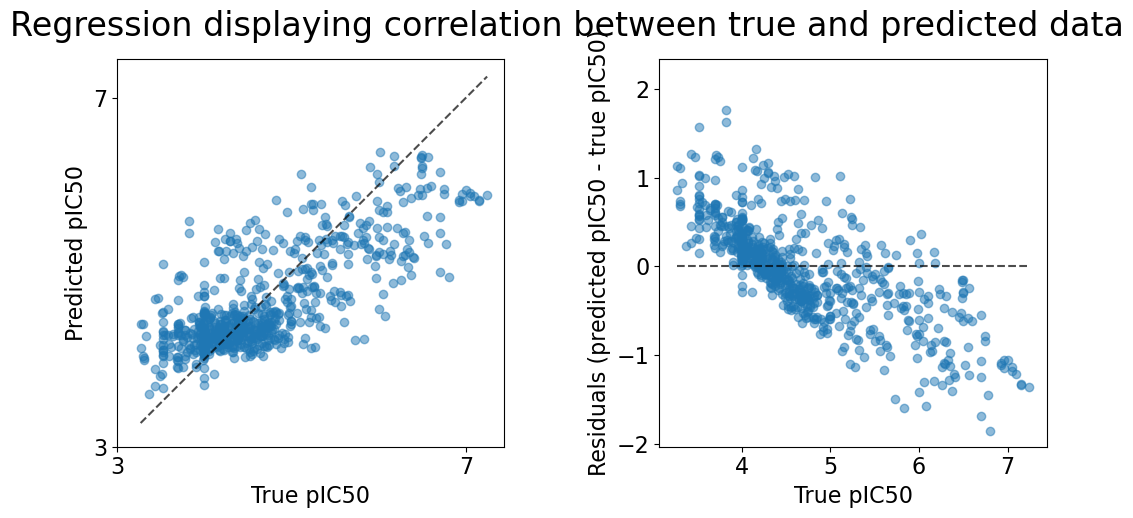

In [22]:
plot_cv_results(y_dataB, y_predictionsB, log=True)

# Without dataset augmentation (i.e. permutations)

We suppress the call to 'ligands_permutation' in 'prepare_train_set', line 565 of utils.py.

## Standard splitting

In [ ]:
metals_rdkit_copy = metals_rdkit.copy()

X = np.array(metals_rdkit_copy['Descriptors'].values.tolist())
y = np.array(metals_rdkit_copy['pIC50'].values.tolist())

indices_metals = get_indices(metals_rdkit_copy, CV=10, shuffle = True)

In [ ]:
y_data, y_predictions = cross_validation(metals_rdkit_copy, indices_metals, X, y, rf, descriptors=True, permutation=False)

In [ ]:
plot_cv_results(y_data, y_predictions, log=True)

#### On HeLa cells

In [ ]:
metals_hela = metals_rdkit.copy()
metals_hela = metals_hela[metals_hela['Cells'] == 'HeLa']
metals_hela.reset_index(drop=True, inplace=True)

X_hela = np.array(metals_hela['Descriptors'].values.tolist())
y_hela = np.array(metals_hela['pIC50'].values.tolist())

indices_hela = get_indices(metals_hela, CV=10, shuffle=True)

In [ ]:
y_data_hela, y_predictions_hela = cross_validation(metals_hela, indices_hela, X_hela, y_hela, rf, descriptors=True, permutation=False)

In [ ]:
plot_cv_results(y_data_hela, y_predictions_hela)

## DOI splitting

In [ ]:
metals_doi_copy = metals_rdkit.copy()

#We drop any row where the descriptors contains a NaN value, as the model will not take any NaN value.
for index, array in enumerate(metals_doi_copy['Descriptors']):
    if np.isnan(array).any():
        metals_doi_copy.drop(index, inplace=True)
metals_doi_copy.reset_index(drop=True, inplace=True)

X_doi = np.array(metals_doi_copy['Descriptors'].values.tolist())
y_doi = np.array(metals_doi_copy['pIC50'].values.tolist())

indices_metals_doi = get_indices_doi(metals_doi_copy, CV=10)

In [ ]:
y_data_doi, y_predictions_doi = cross_validation(metals_doi_copy, indices_metals_doi, X_doi, y_doi, rf, descriptors=True, permutation=False)

In [ ]:
plot_cv_results(y_data_doi, y_predictions_doi, log=True)

#### On HeLa cells

In [ ]:
metals_doi_hela = metals_rdkit.copy()
metals_doi_hela = metals_doi_hela[metals_doi_hela['Cells'] == 'HeLa']

#We drop any row where the descriptors contains a NaN value, as the model will not take any NaN value.
for index, array in enumerate(metals_doi_hela['Descriptors']):
    if np.isnan(array).any():
        metals_doi_hela.drop(index, inplace=True)
metals_doi_hela.reset_index(drop=True, inplace=True)

X_doi_hela = np.array(metals_doi_hela['Descriptors'].values.tolist())
y_doi_hela = np.array(metals_doi_hela['pIC50'].values.tolist())

indices_metals_hela_doi = get_indices_doi(metals_doi_hela, CV=10)

In [ ]:
y_data_doi_hela, y_predictions_doi_hela = cross_validation(metals_doi_hela, indices_metals_hela_doi, X_doi_hela, y_doi_hela, rf, descriptors=True, permutation=False)

In [ ]:
plot_cv_results(y_data_doi_hela, y_predictions_doi_hela, log=True)

## Scaffold splitting

#### On ligand A:

In [ ]:
metals_A = metals_rdkit.copy()

#We drop any row where the descriptors contains a NaN value, as the model will not take any NaN value.
for index, array in enumerate(metals_A['Descriptors']):
    if np.isnan(array).any():
        metals_A.drop(index, inplace=True)
metals_A.reset_index(drop=True, inplace=True)

metals_A = average_duplicates(metals_A, 'Descriptors', 'pIC50')

X_A = np.array(metals_A['Descriptors'].values.tolist())
y_A = np.array(metals_A['pIC50'].values.tolist())

molsA = metals_A['MOL1'].tolist()

# We must extract the mol objects as the get_indices_scaff take a list of mol objects as argument, not a dataframe

indicesA = get_indices_scaff(molsA, CV=10)

In [ ]:
y_dataA, y_predictionsA = cross_validation(metals_A, indicesA, X_A, y_A, rf, descriptors=True, permutation=False)

In [ ]:
plot_cv_results(y_dataA, y_predictionsA, log=True)

#### On ligand B :

In [ ]:
metals_B = metals_rdkit.copy()

#We drop any row where the descriptors contains a NaN value, as the model will not take any NaN value.
for index, array in enumerate(metals_B['Descriptors']):
    if np.isnan(array).any():
        metals_B.drop(index, inplace=True)
metals_B.reset_index(drop=True, inplace=True)

#drop_duplicates(metals_B, 'Fingerprint')
metals_B = average_duplicates(metals_B, 'Descriptors', 'pIC50')

X_B = np.array(metals_B['Descriptors'].values.tolist())
y_B = np.array(metals_B['pIC50'].values.tolist())

molsB = metals_B['MOL3'].tolist()

# We must extract the mol objects as the get_indices_scaff take a list of mol objects as argument, not a dataframe

indicesB = get_indices_scaff(molsB, CV=10)

In [ ]:
y_dataB, y_predictionsB = cross_validation(metals_B, indicesB, X_B, y_B, rf, descriptors=True, permutation=False)

In [ ]:
plot_cv_results(y_dataB, y_predictionsB, log=True)

# Comparing the predictions of both models : fingerprints and descriptors

## Definition of the two models

In [ ]:
rf_fp = RandomForestRegressor(max_depth=15, n_estimators=50, min_samples_leaf=1, max_features=0.5, random_state=42)

In [ ]:
rf_desc = RandomForestRegressor(max_depth=26, n_estimators=390, min_samples_leaf=1, max_features=0.5, random_state=42)

## Standart Splitting

#### On the whole dataset

In [ ]:
metals_rdkit_copy = metals_rdkit.copy()

X = np.array(metals_rdkit_copy['Fingerprint'].values.tolist())
y = np.array(metals_rdkit_copy['pIC50'].values.tolist())

indices_metals = get_indices(metals_rdkit_copy, CV=10, sizes=(0.9, 0.1))

In [9]:
y_data, y_predictions_fp, y_predictions_desc = cross_val_2_models(metals_rdkit_copy, indices_metals, X, y, rf_fp, rf_desc)

CV iteration 0
CV iteration 1
CV iteration 2
CV iteration 3
CV iteration 4
CV iteration 5
CV iteration 6
CV iteration 7
CV iteration 8
CV iteration 9
Metrics for the fingerprints model : {'MAE': 0.3352288501969243, 'RMSE': 0.45968275571966954, 'Ratio': 1.3712505813555038, 'R² Score': 0.7119783606524951}
Metrics for the descriptors model : {'MAE': 0.32098968542599404, 'RMSE': 0.42888070447776055, 'Ratio': 1.3361198940351664, 'R² Score': 0.7492841971666617}
Metrics for predictions on which both models agree, based on the fingerprints model : {'MAE': 0.2999512437722567, 'RMSE': 0.4073257214291179, 'Ratio': 1.3579731035834184, 'R² Score': 0.758708664237628}
Metrics for predictions on which both models agree, based on the descriptors model : {'MAE': 0.29396482418290465, 'RMSE': 0.39279988351624123, 'Ratio': 1.3362138977275781, 'R² Score': 0.7756114162268369}
Metrics for predictions on which both models disagree, based on the fingerprints model : {'MAE': 0.5885862054286275, 'RMSE': 0.7330208

#### On HeLa cells

In [6]:
metals_hela = metals_rdkit.copy()
metals_hela = metals_hela[metals_hela['Cells'] == 'HeLa']
metals_hela.reset_index(drop=True, inplace=True)

X_hela = np.array(metals_hela['Descriptors'].values.tolist())
y_hela = np.array(metals_hela['pIC50'].values.tolist())

indices_hela = get_indices(metals_hela, CV=10, sizes=(0.9, 0.1))

train length : 164 | test length : 19
164 19
train length : 164 | test length : 19
164 19
train length : 164 | test length : 19
164 19
train length : 164 | test length : 19
164 19
train length : 164 | test length : 19
164 19
train length : 164 | test length : 19
164 19
train length : 164 | test length : 19
164 19
train length : 164 | test length : 19
164 19
train length : 164 | test length : 19
164 19
train length : 164 | test length : 19
164 19


In [10]:
y_data_hela, y_predictions_hela_fp, y_predictions_hela_desc = cross_val_2_models(metals_hela, indices_hela, X_hela, y_hela, rf_fp, rf_desc)

CV iteration 0
CV iteration 1
CV iteration 2
CV iteration 3
CV iteration 4
CV iteration 5
CV iteration 6
CV iteration 7
CV iteration 8
CV iteration 9
Metrics for the fingerprints model : {'MAE': 0.2704011539938914, 'RMSE': 0.37850326451503674, 'Ratio': 1.3997842055200231, 'R² Score': 0.4055400048471519}


Metrics for the descriptors model : {'MAE': 0.2654941046987536, 'RMSE': 0.3729403568224786, 'Ratio': 1.4047029678705683, 'R² Score': 0.4228852974450762}


Metrics for predictions on which both models agree, based on the fingerprints model : {'MAE': 0.2581997550591277, 'RMSE': 0.36360905850094605, 'Ratio': 1.408247108591097, 'R² Score': 0.41998825469022205}
Metrics for predictions on which both models agree, based on the descriptors model : {'MAE': 0.2538007445933097, 'RMSE': 0.3531603984077574, 'Ratio': 1.3914868491566548, 'R² Score': 0.45284371015079805}


Metrics for predictions on which both models disagree, based on the fingerprints model : {'MAE': 0.5479829797597671, 'RMSE': 0.62

## DOI splitting

In [11]:
metals_doi_copy = metals_rdkit.copy()
metals_doi_copy.reset_index(drop=True, inplace=True)

X_doi = np.array(metals_doi_copy['Fingerprint'].values.tolist())
y_doi = np.array(metals_doi_copy['pIC50'].values.tolist())

indices_metals_doi = get_indices_doi(metals_doi_copy, CV=10, sizes=(0.9, 0.1))

train length : 645 | test length : 72
train length : 650 | test length : 67
train length : 656 | test length : 61
train length : 656 | test length : 61
train length : 625 | test length : 92
train length : 660 | test length : 57
train length : 644 | test length : 73
train length : 656 | test length : 61
train length : 642 | test length : 75
train length : 619 | test length : 98


In [12]:
y_data_doi, y_predictions_doi_fp, y_predictions_doi_desc = cross_val_2_models(metals_doi_copy, indices_metals_doi, X_doi, y_doi, rf_fp, rf_desc)

CV iteration 0
CV iteration 1
CV iteration 2
CV iteration 3
CV iteration 4
CV iteration 5
CV iteration 6
CV iteration 7
CV iteration 8
CV iteration 9
Metrics for the fingerprints model : {'MAE': 0.5174580599887315, 'RMSE': 0.7073900985192783, 'Ratio': 1.3670481788121782, 'R² Score': 0.2810464026516897}


Metrics for the descriptors model : {'MAE': 0.45728043270960395, 'RMSE': 0.5946408061756853, 'Ratio': 1.3003854170014575, 'R² Score': 0.4919665301987236}


Metrics for predictions on which both models agree, based on the fingerprints model : {'MAE': 0.401771407974993, 'RMSE': 0.5169798250209563, 'Ratio': 1.2867511593884602, 'R² Score': 0.4288801074239458}
Metrics for predictions on which both models agree, based on the descriptors model : {'MAE': 0.38980354852443255, 'RMSE': 0.5046022707113329, 'Ratio': 1.294504046003329, 'R² Score': 0.4559002857101001}


Metrics for predictions on which both models disagree, based on the fingerprints model : {'MAE': 0.8730630528264164, 'RMSE': 1.10318

## Scaffold splitting

#### On ligand A :

In [13]:
metals_A = metals_rdkit.copy()
metals_A.reset_index(drop=True, inplace=True)

X_A = np.array(metals_A['Fingerprint'].values.tolist())
y_A = np.array(metals_A['pIC50'].values.tolist())

# We must extract the mol objects as the get_indices_scaff take a list of mol objects as argument, not a dataframe
molsA = metals_A['MOL1'].tolist()

indicesA = get_indices_scaff(molsA, CV=10, sizes=(0.9, 0.1))

100%|██████████████████████████████████████████████████████████████████████████████| 718/718 [00:00<00:00, 5677.70it/s]

train length : 651 | test length : 67
train length : 689 | test length : 29
train length : 684 | test length : 34
train length : 701 | test length : 17
train length : 706 | test length : 12
train length : 712 | test length : 6
train length : 507 | test length : 211
train length : 705 | test length : 13
train length : 709 | test length : 9
train length : 398 | test length : 320


In [15]:
y_dataA, y_predictionsA_fp, y_predictionsA_desc = cross_val_2_models(metals_A, indicesA, X_A, y_A, rf_fp, rf_desc)

CV iteration 0
CV iteration 1
CV iteration 2
CV iteration 3
CV iteration 4
CV iteration 5
CV iteration 6
CV iteration 7
CV iteration 8
CV iteration 9
Metrics for the fingerprints model : {'MAE': 0.5126114237372614, 'RMSE': 0.7261122056209178, 'Ratio': 1.4164963401070945, 'R² Score': 0.2421109721351148}


Metrics for the descriptors model : {'MAE': 0.499092105261837, 'RMSE': 0.6518685160771942, 'Ratio': 1.306108650496899, 'R² Score': 0.3891730958352416}


Metrics for predictions on which both models agree, based on the fingerprints model : {'MAE': 0.4086076212670311, 'RMSE': 0.5209475331026944, 'Ratio': 1.27493347159633, 'R² Score': 0.49224355340356474}
Metrics for predictions on which both models agree, based on the descriptors model : {'MAE': 0.43335020287059345, 'RMSE': 0.5504051144661178, 'Ratio': 1.2701162035234566, 'R² Score': 0.4331966662274437}


Metrics for predictions on which both models disagree, based on the fingerprints model : {'MAE': 0.6734116289749226, 'RMSE': 0.9606312

#### On ligand B

In [16]:
metals_B = metals_rdkit.copy()
metals_B.reset_index(drop=True, inplace=True)

X_B = np.array(metals_B['Fingerprint'].values.tolist())
y_B = np.array(metals_B['pIC50'].values.tolist())

# We must extract the mol objects as the get_indices_scaff take a list of mol objects as argument, not a dataframe
molsB = metals_B['MOL3'].tolist()

indicesB = get_indices_scaff(molsB, CV=10, sizes=(0.9, 0.1))

100%|██████████████████████████████████████████████████████████████████████████████| 718/718 [00:00<00:00, 3584.31it/s]

train length : 676 | test length : 42
train length : 577 | test length : 141
train length : 672 | test length : 46
train length : 594 | test length : 124
train length : 673 | test length : 45
train length : 677 | test length : 41
train length : 601 | test length : 117
train length : 647 | test length : 71
train length : 674 | test length : 44
train length : 671 | test length : 47


In [17]:
y_dataB, y_predictionsB_fp, y_predictionsB_desc = cross_val_2_models(metals_B, indicesB, X_B, y_B, rf_fp, rf_desc)

CV iteration 0
CV iteration 1
CV iteration 2
CV iteration 3
CV iteration 4
CV iteration 5
CV iteration 6
CV iteration 7
CV iteration 8
CV iteration 9
Metrics for the fingerprints model : {'MAE': 0.4810454483320736, 'RMSE': 0.642007329980847, 'Ratio': 1.3346084703781642, 'R² Score': 0.4075139647028513}


Metrics for the descriptors model : {'MAE': 0.42138254679090653, 'RMSE': 0.5441755306614028, 'Ratio': 1.2914050066991198, 'R² Score': 0.5743269410055917}


Metrics for predictions on which both models agree, based on the fingerprints model : {'MAE': 0.3555547418489916, 'RMSE': 0.45911493816223975, 'Ratio': 1.2912637187025098, 'R² Score': 0.5122005750085865}
Metrics for predictions on which both models agree, based on the descriptors model : {'MAE': 0.3505271768291451, 'RMSE': 0.45178286077355995, 'Ratio': 1.2888668572302147, 'R² Score': 0.5276565045673243}


Metrics for predictions on which both models disagree, based on the fingerprints model : {'MAE': 0.7972328166276819, 'RMSE': 0.958